# Lesson 02 workbook — Build an edge detector

Compute gradients, control noise, and select Canny thresholds.

## Setup

Load the same photograph and controlled edge scene as the run-through.

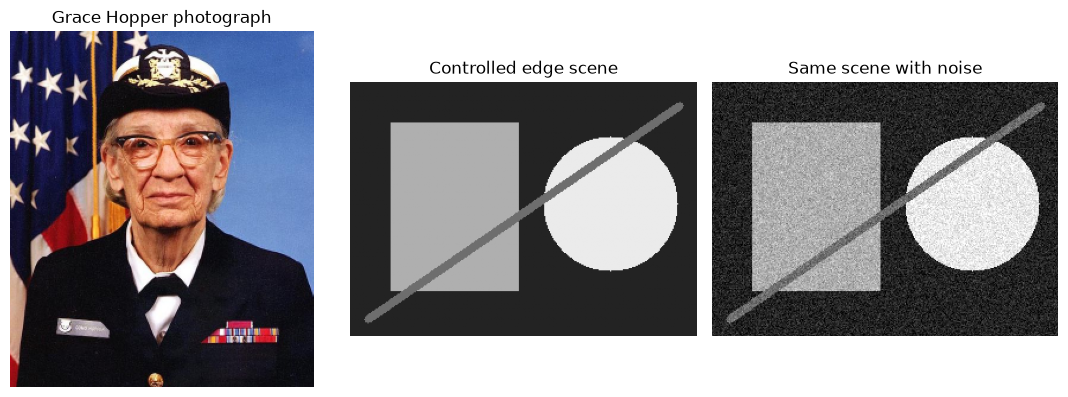

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02-workbook\00-inputs.png
Results directory: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02-workbook
OpenCV: 5.0.0


In [9]:
from pathlib import Path

import cv2
from matplotlib import cbook
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError(
        "No Git repository root was found. The notebook must run inside "
        "the assigned repository."
    )


def normalize_u8(image):
    return cv2.normalize(
        np.asarray(image, dtype=np.float32),
        None,
        0,
        255,
        cv2.NORM_MINMAX,
    ).astype(np.uint8)


def plot_image(axis, image, title, display="gray"):
    image_array = np.asarray(image)
    if display == "rgb":
        axis.imshow(image_array)
    elif display == "signed":
        scale = max(float(np.percentile(np.abs(image_array), 99)), 1.0)
        axis.imshow(image_array, cmap="coolwarm", vmin=-scale, vmax=scale)
    else:
        axis.imshow(image_array, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")


def save_figure(figure, filename):
    output_path = RESULTS_DIR / filename
    figure.tight_layout()
    figure.savefig(output_path, dpi=110, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    return output_path


def make_edge_scene(height=220, width=300, seed=7):
    rng = np.random.default_rng(seed)
    image = np.full((height, width), 35, dtype=np.uint8)
    cv2.rectangle(image, (35, 35), (145, 180), 175, -1)
    cv2.circle(image, (225, 105), 58, 235, -1)
    cv2.line(image, (15, 205), (285, 20), 110, 5)
    noise = rng.normal(0, 18, image.shape)
    noisy = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return image, noisy


REPO_ROOT = find_repository_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results" / "lesson-02-workbook"
if REPO_ROOT not in RESULTS_DIR.parents:
    raise RuntimeError("Results directory is outside the repository")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PHOTO_PATH = Path(cbook.get_sample_data("grace_hopper.jpg", asfileobj=False))
photo_bgr = cv2.imread(str(PHOTO_PATH), cv2.IMREAD_COLOR)
if photo_bgr is None:
    raise RuntimeError(f"OpenCV could not read the sample photo: {PHOTO_PATH}")
photo_bgr = cv2.resize(photo_bgr, (256, 300), interpolation=cv2.INTER_AREA)
photo_rgb = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2RGB)
photo_gray = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2GRAY)

clean_scene, noisy_scene = make_edge_scene()
vertical_step = np.full((160, 220), 35, dtype=np.uint8)
vertical_step[:, 110:] = 220
horizontal_step = np.full((160, 220), 35, dtype=np.uint8)
horizontal_step[80:, :] = 220

figure, axes = plt.subplots(1, 3, figsize=(11, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_image(axes[1], clean_scene, "Controlled edge scene")
plot_image(axes[2], noisy_scene, "Same scene with noise")
save_figure(figure, "00-inputs.png")

print("Results directory:", RESULTS_DIR)
print("OpenCV:", cv2.__version__)

## Exercise 1 — Sobel components

Return horizontal and vertical float32 gradients. The checks use vertical, horizontal, and noisy scenes.

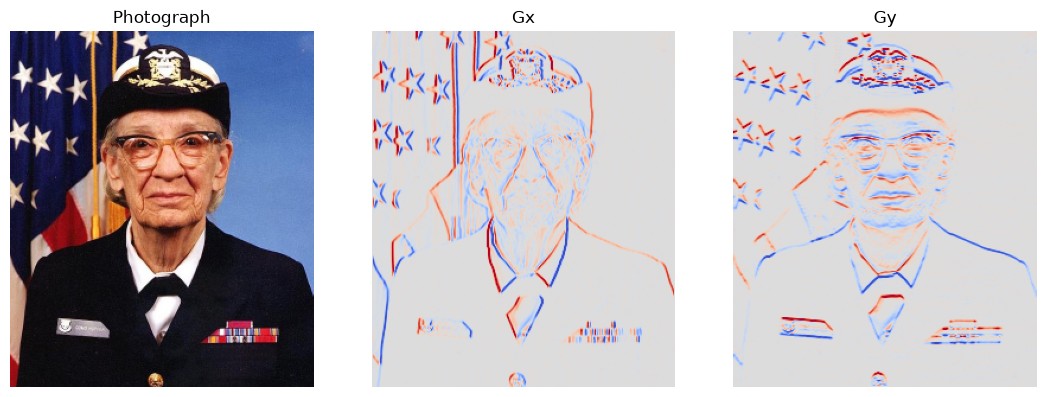

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02-workbook\01-sobel-components.png
PASS — maximum Sobel difference: 0.0


In [10]:
def sobel_components(gray):
    image = np.asarray(gray, dtype=np.float32)
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3, borderType=cv2.BORDER_REFLECT_101)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3, borderType=cv2.BORDER_REFLECT_101)
    return gx, gy


sobel_cases = {
    "vertical": vertical_step,
    "horizontal": horizontal_step,
    "noisy": noisy_scene,
}
sobel_differences = []
for case_name, case_image in sobel_cases.items():
    mine_gx, mine_gy = sobel_components(case_image)
    reference_gx = cv2.Sobel(
        case_image.astype(np.float32),
        cv2.CV_32F,
        1,
        0,
        ksize=3,
        borderType=cv2.BORDER_REFLECT_101,
    )
    reference_gy = cv2.Sobel(
        case_image.astype(np.float32),
        cv2.CV_32F,
        0,
        1,
        ksize=3,
        borderType=cv2.BORDER_REFLECT_101,
    )
    assert mine_gx.shape == mine_gy.shape == case_image.shape
    assert mine_gx.dtype == mine_gy.dtype == np.float32
    case_difference = max(
        float(np.max(np.abs(mine_gx - reference_gx))),
        float(np.max(np.abs(mine_gy - reference_gy))),
    )
    assert case_difference <= 1e-4, (
        f"{case_name} Sobel difference: {case_difference}"
    )
    sobel_differences.append(case_difference)

max_sobel_difference = max(sobel_differences)
gx_photo, gy_photo = sobel_components(photo_gray)
figure, axes = plt.subplots(1, 3, figsize=(11, 4))
plot_image(axes[0], photo_rgb, "Photograph", display="rgb")
plot_image(axes[1], gx_photo, "Gx", display="signed")
plot_image(axes[2], gy_photo, "Gy", display="signed")
save_figure(figure, "01-sobel-components.png")
print("PASS — maximum Sobel difference:", max_sobel_difference)

## Exercise 2 — Magnitude and direction

Combine Gx and Gy into edge strength and direction in degrees.

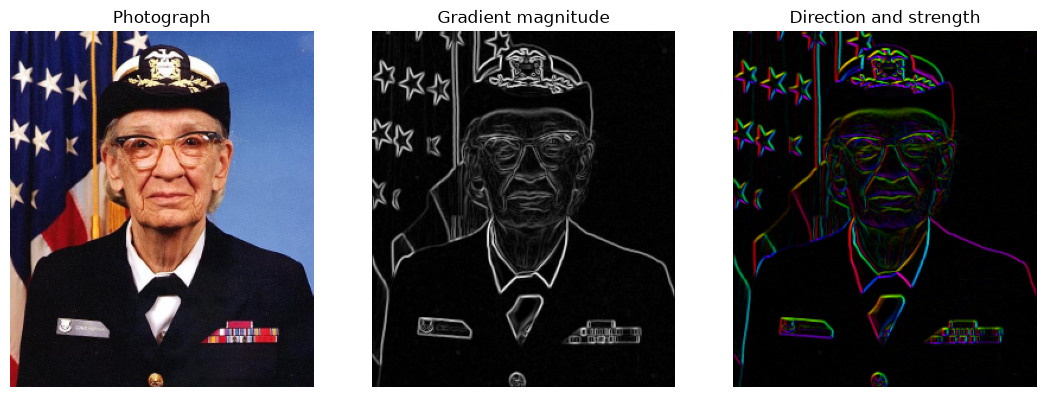

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02-workbook\02-magnitude-and-direction.png
PASS — magnitude difference: 0.0
PASS — direction difference: 0.0


In [11]:
def magnitude_and_direction(gx, gy):
    gx_array = np.asarray(gx, dtype=np.float32)
    gy_array = np.asarray(gy, dtype=np.float32)
    magnitude = cv2.magnitude(gx_array, gy_array)
    direction = cv2.phase(gx_array, gy_array, angleInDegrees=True)
    return magnitude, direction


magnitude_photo, direction_photo = magnitude_and_direction(gx_photo, gy_photo)
reference_magnitude = cv2.magnitude(gx_photo, gy_photo)
reference_direction = cv2.phase(gx_photo, gy_photo, angleInDegrees=True)

assert magnitude_photo.shape == direction_photo.shape == photo_gray.shape
assert magnitude_photo.dtype == direction_photo.dtype == np.float32
max_magnitude_difference = float(
    np.max(np.abs(magnitude_photo - reference_magnitude))
)
strong_pixels = reference_magnitude > np.percentile(reference_magnitude, 60)
wrapped_direction_error = np.abs(
    ((direction_photo - reference_direction + 180.0) % 360.0) - 180.0
)
max_direction_difference = float(np.max(wrapped_direction_error[strong_pixels]))
assert max_magnitude_difference <= 1e-4
assert max_direction_difference <= 0.1

display_magnitude = normalize_u8(magnitude_photo)
hsv = np.zeros((*photo_gray.shape, 3), dtype=np.uint8)
hsv[..., 0] = np.mod(direction_photo / 2.0, 180).astype(np.uint8)
hsv[..., 1] = 255
hsv[..., 2] = display_magnitude
direction_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

figure, axes = plt.subplots(1, 3, figsize=(11, 4))
plot_image(axes[0], photo_rgb, "Photograph", display="rgb")
plot_image(axes[1], display_magnitude, "Gradient magnitude")
plot_image(axes[2], direction_rgb, "Direction and strength", display="rgb")
save_figure(figure, "02-magnitude-and-direction.png")
print("PASS — magnitude difference:", max_magnitude_difference)
print("PASS — direction difference:", max_direction_difference)

## Exercise 3 — Noise and smoothing

Run Canny before and after Gaussian smoothing with the same thresholds. Measure false edges outside the known shapes.

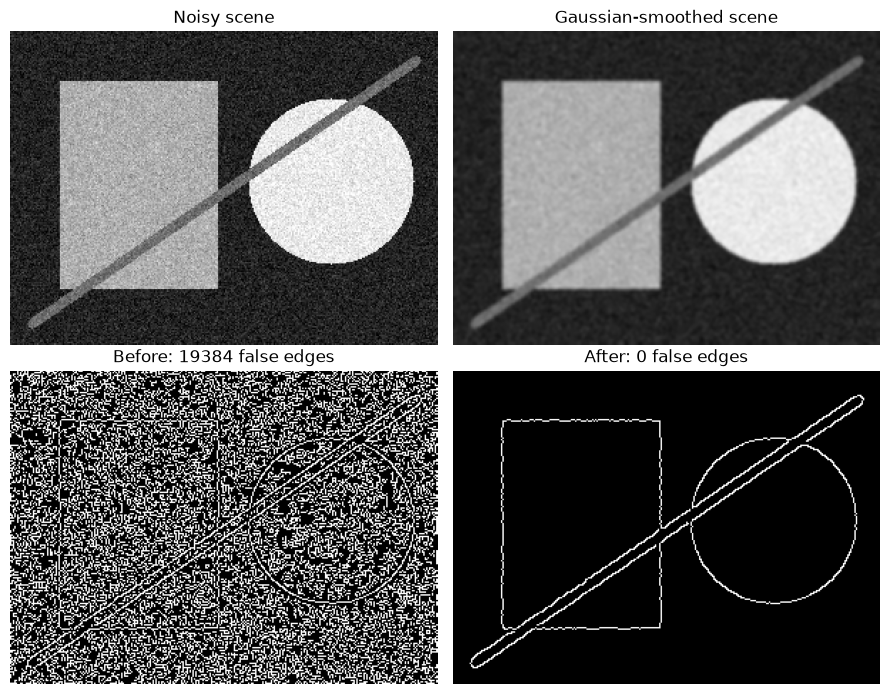

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02-workbook\03-noise-comparison.png
PASS — false edges before smoothing: 19384
PASS — false edges after smoothing: 0


In [12]:
def compare_smoothing_edges(noisy, low, high):
    noisy_array = np.asarray(noisy, dtype=np.uint8)
    smoothed = cv2.GaussianBlur(noisy_array, (5, 5), 1.2)
    noisy_edges = cv2.Canny(noisy_array, low, high)
    smoothed_edges = cv2.Canny(smoothed, low, high)
    return smoothed, noisy_edges, smoothed_edges


canny_low, canny_high = 60, 140
smoothed_scene, noisy_edges, smoothed_edges = compare_smoothing_edges(
    noisy_scene,
    canny_low,
    canny_high,
)
reference_smoothed = cv2.GaussianBlur(noisy_scene, (5, 5), 1.2)
reference_noisy_edges = cv2.Canny(noisy_scene, canny_low, canny_high)
reference_smoothed_edges = cv2.Canny(
    reference_smoothed,
    canny_low,
    canny_high,
)
assert np.array_equal(smoothed_scene, reference_smoothed)
assert np.array_equal(noisy_edges, reference_noisy_edges)
assert np.array_equal(smoothed_edges, reference_smoothed_edges)

clean_edges = cv2.Canny(clean_scene, canny_low, canny_high)
edge_support = cv2.dilate(
    clean_edges,
    np.ones((5, 5), dtype=np.uint8),
    iterations=1,
) > 0
false_edges_before = int(np.count_nonzero(noisy_edges[~edge_support]))
false_edges_after = int(np.count_nonzero(smoothed_edges[~edge_support]))
assert false_edges_after < false_edges_before

figure, axes = plt.subplots(2, 2, figsize=(9, 7))
plot_image(axes[0, 0], noisy_scene, "Noisy scene")
plot_image(axes[0, 1], smoothed_scene, "Gaussian-smoothed scene")
plot_image(axes[1, 0], noisy_edges, f"Before: {false_edges_before} false edges")
plot_image(axes[1, 1], smoothed_edges, f"After: {false_edges_after} false edges")
save_figure(figure, "03-noise-comparison.png")
print("PASS — false edges before smoothing:", false_edges_before)
print("PASS — false edges after smoothing:", false_edges_after)

## Open problem — Select Canny thresholds

Choose a low and high threshold for the photograph. Save the edge map and overlay, then explain the detail and noise tradeoff.

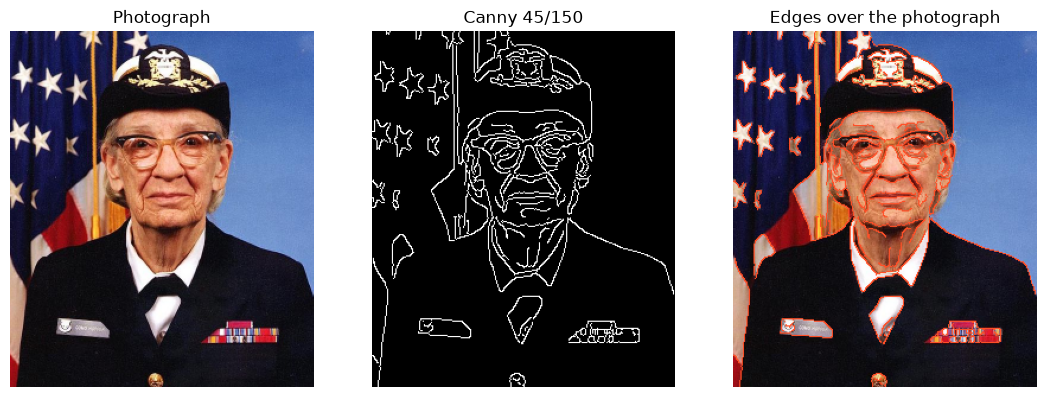

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02-workbook\04-threshold-design.png
opencv_version=5.0.0
sobel_max_difference=0.00000000
max_magnitude_difference=0.00000000
direction_max_difference=0.00000000
false_edges_before=19384
false_edges_after=0
chosen_canny_low=45
chosen_canny_high=150
chosen_edge_pixels=5240
threshold_reason=A low value allows more noise but also better edge detection, while a high value ignores noise but also has less detection because the threshold is higher.



In [14]:
my_low = 45
my_high = 150
my_threshold_reason = "A low value allows more noise but also better edge detection, while a high value ignores noise but also has less detection because the threshold is higher."  # TODO: explain the tradeoff in at least 20 words.


if my_low is None or my_high is None:
    raise RuntimeError("Record both Canny thresholds")
if not isinstance(my_low, (int, np.integer)) or not isinstance(
    my_high,
    (int, np.integer),
):
    raise TypeError("Canny thresholds must be integers")
if not 0 <= my_low < my_high <= 255:
    raise ValueError("Canny thresholds must satisfy 0 <= low < high <= 255")
if len(my_threshold_reason.split()) < 20:
    raise RuntimeError("Explain the threshold choice in at least 20 words")

photo_smoothed = cv2.GaussianBlur(photo_gray, (5, 5), 1.2)
chosen_edges = cv2.Canny(photo_smoothed, my_low, my_high)
chosen_edge_count = int(np.count_nonzero(chosen_edges))
if not 0 < chosen_edge_count < chosen_edges.size:
    raise RuntimeError("The selected thresholds must produce a nonempty edge map")

overlay = photo_rgb.copy()
overlay[chosen_edges > 0] = np.array([255, 80, 40], dtype=np.uint8)
figure, axes = plt.subplots(1, 3, figsize=(11, 4))
plot_image(axes[0], photo_rgb, "Photograph", display="rgb")
plot_image(axes[1], chosen_edges, f"Canny {my_low}/{my_high}")
plot_image(axes[2], overlay, "Edges over the photograph", display="rgb")
save_figure(figure, "04-threshold-design.png")

measurements = (
    f"opencv_version={cv2.__version__}\n"
    f"sobel_max_difference={max_sobel_difference:.8f}\n"
    f"max_magnitude_difference={max_magnitude_difference:.8f}\n"
    f"direction_max_difference={max_direction_difference:.8f}\n"
    f"false_edges_before={false_edges_before}\n"
    f"false_edges_after={false_edges_after}\n"
    f"chosen_canny_low={my_low}\n"
    f"chosen_canny_high={my_high}\n"
    f"chosen_edge_pixels={chosen_edge_count}\n"
    f"threshold_reason={my_threshold_reason.strip()}\n"
)
(RESULTS_DIR / "measurements.txt").write_text(measurements, encoding="utf-8")
print(measurements)

## Questions

1. Why does a vertical brightness edge produce a large Gx response? Because moving horizontally detects changes vertically-edges that are vertical are detected in the Gx direction.
2. What information is lost when signed gradients become magnitude? The sign-we know the strength of the change but not what kind of change is happening (getting brighter or darker).
3. Why does Gaussian smoothing reduce false edges from noise? True edges are surrounded with pixels that are sharper (these standout more) and so the algorithm does not see them as a mistake or noise, while false edges are like spikes in a flat plane-they standout and are averaged out with the surrounding pixels by the algorithm.
4. List the Canny stages and explain the connectivity step. A Canny algorithm smooths the image, measures its gradients, thins spikes, applies two thresholds, and keeps weak edges connected to strong edges. The connectivity step preserves contour in the image-it preserves weak edges that are near strong edges in order to discard noise but keep the tiny edges that still contribute to the image.
5. Why can a separable Gaussian filter match a full 2-D Gaussian filter? Because they both pass in the x and y directions-the separable does a pass in one direction and then in the other while the 2D works in both simultaneously.

Commit the executed workbook and `results/lesson-02-workbook/`, then push.

Sources: [OpenCV image gradients](https://docs.opencv.org/5.0/tutorials/imgproc/imgtrans/sobel_derivatives/sobel_derivatives.html) · [OpenCV Canny edge detection](https://docs.opencv.org/5.0/tutorials/imgproc/imgtrans/canny_detector/canny_detector.html)